<a href="https://colab.research.google.com/github/shreyanshxt/brain-tumor-/blob/main/BRAIN_TUMOR3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nibabel


In [ ]:
!pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 83.8 MB/s eta 0:00:00


In [ ]:
####Stack or Train]   → [SUV, CBF] as input to your ViT


In [ ]:
!pip install antspyx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 86.9 MB/s eta 0:00:00


In [ ]:
import nibabel as nib
import ants
import os
from os import path
import numpy as np

In [ ]:
#aligning the two suv and cbf
import nibabel as nib
import ants
import os
from os import path
import numpy as np
#loop to go through all teh files
suv_img_path="/content/sub-patient18_SUV_z.nii"
cbf_img_path="/content/sub-patient18_cbf.nii"


base, ext = os.path.splitext(suv_img_path)
cbf_img=ants.image_read(cbf_img_path)
suv_img=ants.image_read(suv_img_path)
suv_nii=nib.load(suv_img_path)
cbf_nii=nib.load(cbf_img_path)

img_cor_suv = ants.n4_bias_field_correction(suv_img)

img_cor_cbf = ants.n4_bias_field_correction(cbf_img)
# spacing
def spacing(affine):
  affine_data= affine.affine.astype(np.float64)
  return tuple(np.sqrt((affine_data[:3, :3] ** 2).sum(axis=0)))

#min max normalization
def minmax(img_ants):
  data=img_ants.numpy()
  normalized=(data-data.min())/(data.max()-data.min() + 1e-8)
  normalized = np.nan_to_num(normalized, nan=0.0, posinf=0.0, neginf=0.0)
  affine=ants_affine(img_ants)
  new_img = nib.Nifti1Image(
        normalized,
        affine
    )
  return new_img # Return the new nibabel image

# define affine matrix
def ants_affine (img_ants):
  spacing=np.array(img_ants.spacing)
  direction=np.array(img_ants.direction)
  origin=np.array(img_ants.origin)
  affine=np.eye(4)
  for i in range(3):
    affine[i,:3]=direction[i]*spacing[i]

  affine[:3,3]=origin
  return affine


norm_suv=minmax(img_cor_suv)
norm_cbf=minmax(img_cor_cbf)

#covert npy->ants
ants_suv=ants.from_numpy(norm_suv.get_fdata())
ants_cbf=ants.from_numpy(norm_cbf.get_fdata())

#registration
reg=ants.registration(fixed=ants_suv,moving=ants_cbf,type_of_transform='SyN')
aligned_suv=reg['warpedmovout']
suv_reg=base+'_registered_'+ext
ants.image_write(aligned_suv,suv_reg)

In [ ]:
!pip install scikit-learn


In [ ]:
#image padding
def ants_img_pad(ants_img):
  data=ants_img.numpy()
  spacing = ants_img.spacing
  origin=ants_img.origin
  direction=ants_img.direction

  x,y,z =data.shape
  pad_x=max(0,256-x)
  pad_y=max(0,256-y)
  pad_z=max(0,256-z)

  pad_width=(
      (pad_x//2,pad_x-pad_x//2),
      (pad_y//2,pad_y-pad_y//2),
      (pad_z//2,pad_z-pad_z//2),
  )
  padded_data=np.pad(data,pad_width,mode='constant',constant_values=0)
  padded_img =ants.from_numpy(
      padded_data,
      spacing=spacing,
      origin=origin,
      direction=direction
  )
  return padded_img


In [ ]:
img = ants.image_read('/content/sub-patient18_SUV_z_registered_.nii')
padded_img1 = ants_img_pad(img)
padded_img_path1=os.path.splitext('/content/sub-patient18_SUV_z_registered_.nii')[0]+"_padded_"+os.path.splitext("/content/sub-patient18_SUV_z_registered_.nii")[1]
img = ants.image_read('/content/sub-patient18_cbf.nii')
padded_img2 = ants_img_pad(img)
padded_img_path2=os.path.splitext('/content/sub-patient18_cbf.nii')[0]+"_padded_"+os.path.splitext("/content/sub-patient18_cbf")[1]

In [ ]:
img = ants.image_read('/content/BraTS2021_00621_seg.nii')
padded_img3 = ants_img_pad(img)
padded_img_path3=os.path.splitext('/content/BraTS2021_00621_seg.nii')[0]+"_padded_"+os.path.splitext("/content/BraTS2021_00621_seg.nii")[1]
nib.save(padded_img3, padded_img_path3)
img = ants.image_read('/content/BraTS20_Training_001_seg.nii')
padded_img4 = ants_img_pad(img)
padded_img_path4=os.path.splitext('/content/BraTS20_Training_001_seg.nii')[0]+"_padded_"+os.path.splitext("/content/BraTS20_Training_001_seg.nii")[1]
nib.save(padded_img4, padded_img_path4)

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.9 MB/s eta 0:00:00


In [ ]:
# CBAM
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, GlobalAveragePooling3D, Dense, Multiply, Reshape, GlobalMaxPooling3D,Activation,Concatenate
from tensorflow.keras.models import Model,Sequential


class ReduceMeanMax(keras.layers.Layer):
    def __init__(self, axis=-1, keepdims=True, **kwargs):
        super(ReduceMeanMax, self).__init__(**kwargs)
        self.axis = axis
        self.keepdims = keepdims

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=self.axis, keepdims=self.keepdims)
        max_pool = tf.reduce_max(inputs, axis=self.axis, keepdims=self.keepdims)
        return avg_pool, max_pool
def channel_attention (input_tensor,ratio=16):
  channel=input_tensor.shape[-1]
  avg_pool=GlobalAveragePooling3D()(input_tensor)
  max_pool=GlobalMaxPooling3D()(input_tensor)
  mlp=Sequential([
      layers.Dense(channel//ratio,activation='relu'),
      layers.Dense(channel,activation='sigmoid')
  ])
  avg_out=mlp(avg_pool)
  max_out=mlp(max_pool)
  scale=Activation('sigmoid')(avg_out+max_out)
  scale=Reshape((1,1,1,channel))(scale)
  return Multiply()([input_tensor,scale])

def space_attention (input_tensor, kernel_size=7):
  avg_pool, max_pool = ReduceMeanMax(axis=-1, keepdims=True)(input_tensor)
  concat=Concatenate(axis=-1)([avg_pool,max_pool])
  x=Conv3D(filters=1,kernel_size=kernel_size,padding='same',activation='relu')(concat)
  return Multiply()([input_tensor,x])

def cbam(input_tensor,ratio=16,kernel_size=7):
  x=channel_attention(input_tensor)
  #x=space_attention(x,kernel_size)
  return x

In [ ]:
def sque_ex(input_tensor,ratio):
  filter=input_tensor.shape[-1]
  x=GlobalMaxPooling3D()(input_tensor)
  x=Dense(filter//ratio,activation='relu')(x)
  x=Dense(filter,activation='sigmoid')(x)
  x=Reshape((1,1,1,filter))(x)
  x=Multiply()([input_tensor,x])
  return x


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv3D, Concatenate ,GlobalMaxPooling3D, Dense, Multiply, Reshape,MaxPooling3D,Conv3DTranspose
from tensorflow.keras.models import Model

In [ ]:
# ecfusion
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv3D, Concatenate ,GlobalMaxPooling3D, Dense, Multiply, Reshape,MaxPooling3D,Conv3DTranspose
from tensorflow.keras.models import Model

def ecfusion(input_shape):
  mri_input_edge=keras.Input(shape=input_shape, name='MRI_INPUT')
  pet_input_edge=keras.Input(shape=input_shape, name='PET_INPUT')

  mri_feat=Conv3D(filters=64 , kernel_size=(3,3,3), activation='relu',padding='same')(mri_input_edge)
  pet_feat=Conv3D(filters=64,kernel_size=(3,3,3),activation='relu',padding='same')(pet_input_edge)

  fused_img=Concatenate(axis=-1)(inputs=[mri_feat,pet_feat])
  fused_img=Conv3D(filters=128,kernel_size=(3,3,3),activation='relu',padding='same')(fused_img)
  fused_img=Conv3D(filters=128,kernel_size=(3,3,3),activation='relu',padding='same')(fused_img)
  fused_img=sque_ex(fused_img,8)

  #downsample

  fused_img=MaxPooling3D(pool_size=(2,2,2))(fused_img)
  skip=fused_img
  fused_img=Conv3D(filters=256,kernel_size=(3,3,3),activation='relu',padding='same')(fused_img)
  fused_img=Conv3D(filters=256,kernel_size=(3,3,3),activation='relu',padding='same')(fused_img)
  fused_img=cbam(fused_img)
  fused_img=sque_ex(fused_img,8)

  #bottle neck
  fused_img=MaxPooling3D(pool_size=(2,2,2))(fused_img)
  fused_img=Conv3D(filters=512,kernel_size=(3,3,3),activation='relu',padding='same')(fused_img)
  fused_img=cbam(fused_img)
  fused_img=sque_ex(fused_img,8)

  #upsampling
  fused_img=Conv3DTranspose(filters=256, kernel_size=(2,2,2), strides=(2,2,2), padding='same')(fused_img)
  print(fused_img.shape)
  print(skip.shape)

  #skip connection
  x=Concatenate()([fused_img,skip])
  x=Conv3D(filters=128,kernel_size=(3,3,3),activation='relu',padding='same')(x)
  x=cbam(x)
  x=sque_ex(x,8)

  x=Conv3D(filters=64 , kernel_size=(3,3,3), activation='relu',padding='same')(x)
  x=Conv3D(filters=1 , kernel_size=(1,1,1), activation='relu',padding='same')(x)
  return Model(inputs=[mri_input_edge, pet_input_edge], outputs=x, name='ECFusion')

model=ecfusion(input_shape=(256,256,256,1))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

(None, 128, 128, 128, 256)
(None, 128, 128, 128, 128)


Model: "ECFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ MRI_INPUT           │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 256, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PET_INPUT           │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 256, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_134 (Conv3D) │ (None, 256, 256,  │      1,792 │ MRI_INPUT[0][0]   │
│                     │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_135 (Conv3D) │ (None, 256, 256,  │      1,792 │ PET_INPUT[0][0]   │
│                     │ 256, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 256, 256,  │          0 │ conv3d_134[0][0], │
│ (Concatenate)       │ 256, 128)         │            │ conv3d_135[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_136 (Conv3D) │ (None, 256, 256,  │    442,496 │ concatenate_11[0… │
│                     │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_137 (Conv3D) │ (None, 256, 256,  │    442,496 │ conv3d_136[0][0]  │
│                     │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv3d_137[0][0]  │
│ (GlobalMaxPooling3… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │      2,064 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      2,176 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 1,   │          0 │ dense_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 256, 256,  │          0 │ conv3d_137[0][0], │
│ (Multiply)          │ 256, 128)         │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_28    │ (None, 128, 128,  │          0 │ multiply_10[0][0] │
│ (MaxPooling3D)      │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_138 (Conv3D) │ (None, 128, 128,  │    884,992 │ max_pooling3d_28… │
│                     │ 128, 256)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_139 (Conv3D) │ (None, 128, 128,  │  1,769,728 │ conv3d_138[0][0]  │
│                     │ 128, 256)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv3d_139[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ conv3d_139[0][0]  │
│ (GlobalMaxPooling3… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,815,353 (37.44 MB)

 Trainable params: 9,815,353 (37.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
padded_img1.shape


(256, 256, 256)

In [ ]:
mri=padded_img1.numpy().reshape(256,256,256)
mri= np.expand_dims(mri,axis=-1)
mri= np.expand_dims(mri,axis=0)
pet=padded_img2.numpy().reshape(256,256,256)
pet=np.expand_dims(pet,axis=-1)
pet=np.expand_dims(pet,axis=0)
prediction = model.predict([mri,pet])

1/1 ━━━━━━━━━━━━━━━━━━━━ 307s 307s/step


In [ ]:
prediction

array([[[[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         ...,

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]]],


        [[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],


In [ ]:
prediction_squeezed=np.squeeze(prediction)

In [ ]:
prediction_squeezed.shape

(128, 128, 128)

In [ ]:
import numpy as np

# Ensure the squeezed prediction is 3D and cast to float32
if prediction_squeezed.ndim == 3:
    predicted_img_np = prediction_squeezed.astype(np.float32)
    predicted_img = ants.from_numpy(predicted_img_np, spacing=padded_img1.spacing, origin=padded_img1.origin, direction=padded_img1.direction)
    ants.image_write(predicted_img,'predicted_img.nii')
else:
    print(f"Error: Squeezed prediction is not 3D. Shape: {prediction_squeezed.shape}")

Cluster 0: Mean intensity = 0.1720
Cluster 1: Mean intensity = 0.1602
Cluster 2: Mean intensity = 0.1753
Cluster 3: Mean intensity = 0.1701
Cluster 4: Mean intensity = 0.1566

Cluster with highest mean intensity: 2 (Mean = 0.1753)


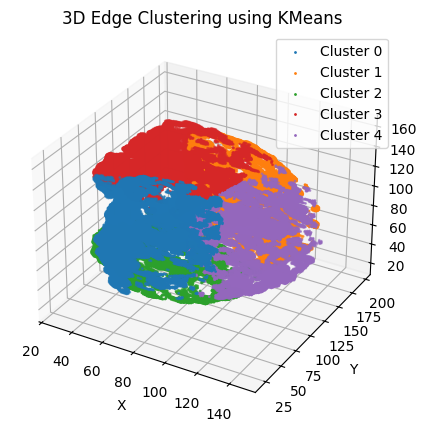

In [ ]:
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# edge map extraction
from scipy import ndimage
def sobel_edge_map(img_reg):
  img_ants = ants.image_read(img_reg)
  data = img_ants.numpy()
  spacing = img_ants.spacing

  sobel_x=ndimage.sobel(data,axis=0)
  sobel_y=ndimage.sobel(data,axis=1)
  sobel_z=ndimage.sobel(data,axis=2)
  edge_map=np.sqrt(sobel_x**2 +sobel_y**2 +sobel_z**2)
  edge_map_norm = (edge_map - edge_map.min()) / (edge_map.max() - edge_map.min() + 1e-8)
  edge_map_norm = np.nan_to_num(edge_map_norm, nan=0.0, posinf=0.0, neginf=0.0)
  ants_edge_img = ants.from_numpy(

      edge_map_norm,
      spacing=img_ants.spacing,
      origin=img_ants.origin,
      direction=img_ants.direction
    )
  edge_map_reg=os.path.splitext(img_reg)[0]+"_edge_map_"+os.path.splitext(img_reg)[1]
#thresholg selection

  threshold= np.percentile(edge_map_norm,98)
  #combined_mask=
  binary_edge = edge_map_norm > threshold
  edge_cord=np.column_stack(np.nonzero(binary_edge))
  edge_strength=edge_map_norm[binary_edge].reshape(-1,1)
  features=np.hstack((edge_cord,edge_strength))
# k-mean clustering
  kmeans=KMeans(n_clusters=5,n_init=20,random_state=1).fit(features)
  labels=kmeans.labels_
#highest kmean
  highest_intensity=[]
  edge_strength_flat=edge_strength.flatten()
  for i in range(5):
    mean = edge_strength[labels == i].mean()
    highest_intensity.append(mean)
  highest_kmean=np.argmax(highest_intensity)
  #print(highest_intensity[highest_kmean])
  for i, mean in enumerate(highest_intensity):
    print(f"Cluster {i}: Mean intensity = {mean:.4f}")

  print(f"\nCluster with highest mean intensity: {highest_kmean} (Mean = {highest_intensity[highest_kmean]:.4f})")

  fig = plt.figure(figsize=(5, 5))
  ax = fig.add_subplot(111, projection='3d')

  for i in range(5):
      cluster_pts = edge_cord[labels == i]
      ax.scatter(cluster_pts[:, 2], cluster_pts[:, 1], cluster_pts[:, 0], s=1, label=f'Cluster {i}')  # x, y, z

  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Z')
  plt.legend()
  plt.title("3D Edge Clustering using KMeans")
  plt.show()

# Save as NIfTI
  ants.image_write(ants_edge_img,edge_map_reg)
#img_reg="predicted_img.nii"
#sobel_edge_map(img_reg)
img_reg="/content/sub-patient18_cbf.nii"
sobel_edge_map(img_reg)

In [ ]:
import matplotlib.pyplot as plt
import ants
import random
def plot_ants_slices(ants_img, title="Slice View"):
    data = ants_img.numpy()
    i=128
    # Get center slice in each axis
    #for i in range(random.randint(1,data.shape[0])):
    x_slice = data[i, :, :]
    y_slice = data[:, i, :]
    z_slice = data[:, :, i]

    # Plot slices
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))
    axes[0].imshow(x_slice.T, cmap="inferno", origin="lower")
    axes[0].set_title('Axial Slice')

    axes[1].imshow(y_slice.T, cmap="inferno", origin="lower")
    axes[1].set_title('Coronal Slice')

    axes[2].imshow(z_slice.T, cmap="inferno", origin="lower")
    axes[2].set_title('Sagittal Slice')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


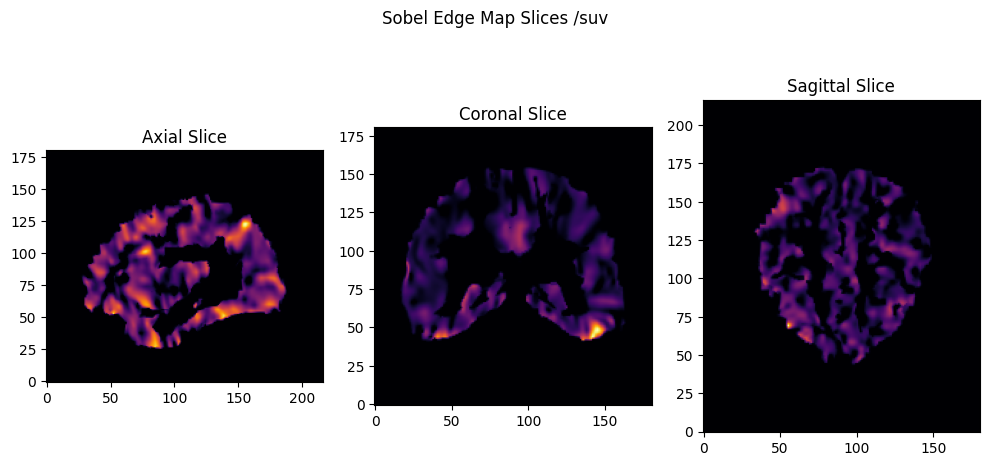

In [ ]:
edge_img1 = ants.image_read("/content/sub-patient18_SUV_z_registered_.nii")
plot_ants_slices(edge_img1, title="Sobel Edge Map Slices /suv")
#edge_img2 = ants.image_read("/content/predicted_img.nii")
#plot_ants_slices(edge_img2, title="Sobel Edge Map Slices /cbf")


In [ ]:
import ants
import numpy as np
from scipy.ndimage import zoom

img = ants.image_read("/content/predicted_img_edge_map_.nii")
img_np = img.numpy()

# down sampling using zoom
compressed_img = zoom(img_np, zoom=0.45)
compressed_ants = ants.from_numpy(compressed_img)


In [ ]:
ants.image_write(compressed_ants,"/content/compressed_img1.nii")

In [ ]:
import plotly.graph_objects as go
import ants
import numpy as np


img = ants.image_read("/content/compressed_img1.nii")
img_np = img.numpy()

# Squeeze if image is 4D
if img_np.ndim == 4:
    img_np = img_np.squeeze()

# Normalize
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

# Get shape
x = np.arange(img_np.shape[0])
y = np.arange(img_np.shape[1])
z = np.arange(img_np.shape[2])
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Create volume figure
fig = go.Figure(data=go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=img_np.flatten(),
    opacity=0.1,
    surface_count=20,
    colorscale='Inferno',
    caps=dict(x_show=False, y_show=False, z_show=False)
))

fig.update_layout(title="3D Medical Volume", width=700, height=700)

# 🔥 Save to file and manually open it
fig.write_html("volume1_plot.html")
print("✅ Plot saved as 'volume1plot.html'. Please open it in your browser.")


✅ Plot saved as 'volume1plot.html'. Please open it in your browser.


In [ ]:
import torch
def CUDA_load(dataset, transpose_data = False, dtype_X = torch.float, dtype_y = torch.float):
    '''
        Pass in iterable in form [ (X0, y0), ..., (Xn, yn) ] (transpose_data = False)
        or [ (X0, ..., Xn), (y0, ..., yn) ] (transpose_data = True), as well as
        data types to convert X and y to if defaults are not desired.

        Returns object to pass into DataLoader as 'dataset' argument. Done this way to
        allow for custom DataLoader to be used.
    '''
    if not transpose_data:
        return list([torch.tensor(X, device = 'cuda', dtype = dtype_X), torch.tensor(y, device = 'cuda', dtype = dtype_y)] for X, y in dataset)
    else:
        return list([torch.tensor(X, device = 'cuda', dtype = dtype_X), torch.tensor(y, device = 'cuda', dtype = dtype_y)] for X, y in zip(*dataset) )

In [ ]:
#mlunet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv3D, Concatenate ,GlobalMaxPooling3D, Dense, Multiply, Reshape,BatchNormalization,MaxPool3D,UpSampling3D,Add,Lambda,Activation
inputs=tf.keras.Input(shape=(256,256,256,1))
def conv_block(x,filters):
  x=Conv3D(filters=filters,kernel_size=(3,3,3),padding='same')(x)
  x=BatchNormalization()(x)
  x=Activation('relu')(x)
  x=Conv3D(filters=filters,kernel_size=(3,3,3),padding='same')(x)
  x=BatchNormalization()(x)
  x=Activation('relu')(x)
  return Activation('relu')(x)

def attention_gate(x,g,channels):
  theta_x=Conv3D(channels,kernel_size=(1,1,1),padding='same')(x)
  phi_g=Conv3D(channels,kernel_size=(1,1,1),padding='same')(g)
  add=Add()([theta_x,phi_g])
  act=Activation('relu')(add)
  psi=Conv3D(1,kernel_size=(1,1,1),padding='same')(act)
  psi=Activation('sigmoid')(psi)
  return Multiply()([x,psi])

def encoder(x,filters):
  f=conv_block(x,filters)
  p=MaxPool3D(pool_size=(2,2,2))(f)
  return f,p

def decoder(x,skip,filters):
  up=UpSampling3D(size=(2,2,2))(x)
  att=attention_gate(skip,up,filters)
  merge=Concatenate()([att,up])
  conv=conv_block(merge,filters)
  return conv
def fft_3d(x):
  def fft_mag(t):
    x_complex=tf.cast(t,tf.complex64)
    x_fft=tf.signal.fft3d(x_complex)
    return tf.abs(x_fft)
  return Lambda(fft_mag)(x)

def mlunet_fft(input_shape):
  inputs=Input(shape=input_shape)
  f1,p1=encoder(inputs,128)
  f2,p2=encoder(p1,64)
  f3,p3=encoder(p2,32)
  f4,p4=encoder(p3,16)

  b_neck=conv_block(p4,256)

  fft_features=fft_3d(b_neck)
  #fft_features=Lambda(lambda x: tf.expand_dims(x,axis=-1))(fft_features)
  fft_processed=Conv3D(256,(1,1,1),padding='same',activation='relu')(fft_features)

  b_combined=Add()([b_neck,fft_processed])

  d4=decoder(b_combined,f4,128)
  d3 = decoder(d4, f3, 64)
  d2 = decoder(d3, f2, 32)
  d1 = decoder(d2, f1, 16)

    # Output
  outputs = Conv3D(1, (1, 1, 1), activation='sigmoid')(d1)

  return Model(inputs, outputs, name="MLUNet3D_FFT")

model2=mlunet_fft(input_shape=(256,256,256,1))
model2.summary()

Model: "MLUNet3D_FFT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 256, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_144 (Conv3D) │ (None, 256, 256,  │      3,584 │ input_layer_16[0… │
│                     │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv3d_144[0][0]  │
│ (BatchNormalizatio… │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_155      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_145 (Conv3D) │ (None, 256, 256,  │    442,496 │ activation_155[0… │
│                     │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv3d_145[0][0]  │
│ (BatchNormalizatio… │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_156      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_157      │ (None, 256, 256,  │          0 │ activation_156[0… │
│ (Activation)        │ 256, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_30    │ (None, 128, 128,  │          0 │ activation_157[0… │
│ (MaxPooling3D)      │ 128, 128)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_146 (Conv3D) │ (None, 128, 128,  │    221,248 │ max_pooling3d_30… │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv3d_146[0][0]  │
│ (BatchNormalizatio… │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_158      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_147 (Conv3D) │ (None, 128, 128,  │    110,656 │ activation_158[0… │
│                     │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv3d_147[0][0]  │
│ (BatchNormalizatio… │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_159      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_160      │ (None, 128, 128,  │          0 │ activation_159[0… │
│ (Activation)        │ 128, 64)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling3d_31    │ (None, 64, 64,    │          0 │ activation_160[0

 Total params: 4,870,693 (18.58 MB)

 Trainable params: 4,867,749 (18.57 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [ ]:
img = ants.image_read("/content/predicted_img.nii")

In [ ]:
# img is loaded in the previous cell (BjU682imohDt)
padded_img = ants_img_pad(img)
mri = padded_img.numpy().reshape(256, 256, 256)
mri = np.expand_dims(mri, axis=-1)
mri = np.expand_dims(mri, axis=0)
prediction2 = model2.predict([mri])

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_180
Received: inputs=('Tensor(shape=(1, 256, 256, 256, 1))',)



1/1 ━━━━━━━━━━━━━━━━━━━━ 196s 196s/step


In [ ]:
prediction

array([[[[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         ...,

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]]],


        [[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],

         [[0.],
          [0.],
          [0.],
          ...,
          [0.],


In [ ]:
import numpy as np

# Assume `output` is the MLUNet prediction, shape: (1, 256, 256, 256, 1) # Remove batch and channel dims

# Threshold
threshold = 0.5
binary_mask = (prediction2 > threshold).astype(np.uint8)


In [ ]:
prediction_squeezed=np.squeeze(binary_mask)

In [ ]:
import numpy as np

# Ensure the squeezed prediction is 3D and cast to float32
if prediction_squeezed.ndim == 3:
    predicted_img_np = prediction_squeezed.astype(np.float32)
    predicted_img = ants.from_numpy(predicted_img_np, spacing=padded_img1.spacing, origin=padded_img1.origin, direction=padded_img1.direction)
    ants.image_write(predicted_img,'predicted_img2.nii')
else:
    print(f"Error: Squeezed prediction is not 3D. Shape: {prediction_squeezed.shape}")

In [ ]:
import ants
import numpy as np
from scipy.ndimage import zoom

img = ants.image_read("/content/predicted_img2.nii")
img_np = img.numpy()

# down sampling using zoom
compressed_img = zoom(img_np, zoom=0.45)
compressed_ants = ants.from_numpy(compressed_img)


In [ ]:
ants.image_write(compressed_ants,"/content/compressed_img2.nii")

In [ ]:
import plotly.graph_objects as go
import ants
import numpy as np


img = ants.image_read("/content/compressed_img2.nii")
img_np = img.numpy()

# Squeeze if image is 4D
if img_np.ndim == 4:
    img_np = img_np.squeeze()

# Normalize
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

# Get shape
x = np.arange(img_np.shape[0])
y = np.arange(img_np.shape[1])
z = np.arange(img_np.shape[2])
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Create volume figure
fig = go.Figure(data=go.Volume(
    x=X.flatten(),
    y=Y.flatten(),
    z=Z.flatten(),
    value=img_np.flatten(),
    opacity=0.1,
    surface_count=20,
    colorscale='Inferno',
    caps=dict(x_show=False, y_show=False, z_show=False)
))

fig.update_layout(title="3D Medical Volume", width=700, height=700)

# 🔥 Save to file and manually open it
fig.write_html("volume2_plot.html")
print("✅ Plot saved as 'volume2plot.html'. Please open it in your browser.")


✅ Plot saved as 'volume2plot.html'. Please open it in your browser.


In [ ]:
pet=padded_img2.numpy().reshape(256,256,256)
pet=np.expand_dims(pet,axis=-1)
pet=np.expand_dims(pet,axis=0)
prediction = model2.predict([mri])